In [58]:
import model
import importlib
importlib.reload(model)
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from mesa.visualization import SolaraViz, SpaceRenderer, make_plot_component
from mesa import batch_run
import numpy as np
import sys

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)
pd.options.display.float_format = "{:.3f}".format

init_variables = {
    # Variables

    "V": 0,
    "M_A": 0,
    # TODO: M_A at t=1 is actually not defined. but setting 0 is justified?

    # prior tendencies for neutral behavior
    "theta_N_w0": 3.892,  # should yield around 95% neutral in the beginning
    "theta_N_w1": 0,

    # prior tendencies for friendly behavior
    "theta_F_w0": 0,
    "theta_F_w1": 0,

    # prior tendencies for aggressive behavior
    "theta_A_w0": 0,
    "theta_A_w1": range(-100, 0),

    # Some variables will be calculated in the model
    # or received from the environment
    "p_N": None,
    "p_A": None,
    "p_F": None,
    "r": None,
    "rpe": None,

    # Parameters

    # Parameter for the exponential moving average of anger
    "lambda_A": 0.60,

    # Controllability
    "C": np.linspace(0, 1, 50)
}

init_variables["theta_N"] = init_variables["theta_N_w0"] + init_variables[
    "theta_N_w1"
]

init_variables["theta_F"] = init_variables["theta_F_w0"] + init_variables[
    "theta_F_w1"
]

init_variables["theta_A"] = init_variables["theta_A_w0"] + init_variables[
    "theta_F_w1"
]

# rng = np.random.default_rng(12345)

# Number of runs per scenario
# seed_values = rng.integers(0, sys.maxsize, size=(5,))

results = batch_run(
    model.IrritabilityModel,
    parameters=init_variables,
    data_collection_period=1,  # collect data for every step
    number_processes=16,
    max_steps=100,
)

# starter_model = model.IrritabilityModel(init_variables=init_variables,
#                                         init_parameters=init_parameters,
#                                         seed=12345)
# Run a simulation for a single agent
# n_ticks = 100
# for _ in range(n_ticks):
#     starter_model.step()
#
# # Extract data and plot
# data = starter_model.datacollector.get_agent_vars_dataframe()
#
# g = sns.lineplot(data=data,
#                  y="p_A",
#                  x="Step",
#                  label="Probability aggressive")
#
# g = sns.lineplot(data=data,
#                  y=data["M_A"].abs(),
#                  x="Step",
#                  color="Orange",
#                  label="Anger/frustration (absolute)")
#
# g.set(title="Anger and aggressive action",
#       ylabel="Value");
#
# plt.xlim(0, 40)
# plt.ylim(0, 1)
# plt.show()
# display(data)

  0%|          | 0/5000 [00:00<?, ?it/s]

0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0

# A glimpse at the data

In [ ]:
results_df = pd.DataFrame(results)

results_df.head(n=200)

# Prior to the first step, many things are not defined (e.g. action)
results_df = results_df[results_df["Step"] > 0]

results_df.head(n=200)

,RunId,iteration,Step,V,M_A,theta_N_w0,theta_N_w1,theta_F_w0,theta_F_w1,theta_A_w0,theta_A_w1,p_N,p_A,p_F,r,rpe,lambda_A,C,theta_N,theta_F,theta_A,AgentID,a
4647,49,0,1,0,0.000,3.892,0,0,0,0,-100,0.961,0.020,0.020,-1.000,-1.000,0.600,1.000,3.892,0,0.000,1.000,NEUTRAL
4648,49,0,2,0,-0.400,3.892,0,0,0,0,-100,0.000,1.000,0.000,0.000,0.000,0.600,1.000,3.892,0,40.000,1.000,AGGRESSIVE
4649,49,0,3,0,-0.240,3.892,0,0,0,0,-100,0.000,1.000,0.000,0.000,0.000,0.600,1.000,3.892,0,24.000,1.000,AGGRESSIVE
4650,49,0,4,0,-0.144,3.892,0,0,0,0,-100,0.000,1.000,0.000,0.000,0.000,0.600,1.000,3.892,0,14.400,1.000,AGGRESSIVE
4651,49,0,5,0,-0.086,3.892,0,0,0,0,-100,0.009,0.991,0.000,0.000,0.000,0.600,1.000,3.892,0,8.640,1.000,AGGRESSIVE
4652,49,0,6,0,-0.052,3.892,0,0,0,0,-100,0.215,0.781,0.004,0.000,0.000,0.600,1.000,3.892,0,5.184,1.000,AGGRESSIVE
4653,49,0,7,0,-0.031,3.892,0,0,0,0,-100,0.677,0.310,0.014,0.000,0.000,0.600,1.000,3.892,0,3.110,1.000,NEUTRAL
4654,49,0,8,0,-0.019,3.892,0,0,0,0,-100,0.868,0.114,0.018,0.000,0.000,0.600,1.000,3.892,0,1.866,1.000,NEUTRAL
4655,49,0,9,0,-0.011,3.892,0,0,0,0,-100,0.923,0.058,0.019,0.000,0.000,0.600,1.000,3.892,0,1.120,1.000,NEUTRAL
4656,49,0,10,0,-0.007,3.892,0,0,0,0,-100,0.943,0.038,0.019,0.000,0.000,0.600,1.000,3.892,0,0.672,1.000,NEUTRAL


# Some plots

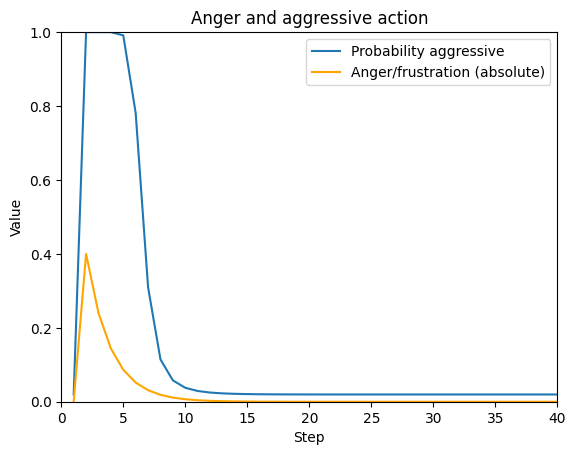

In [75]:
data1 = results_df[(results_df["C"] == 1) &
           (results_df["theta_A_w1"] == -100)]

g = sns.lineplot(data=data1,
                 y="p_A",
                 x="Step",
                 label="Probability aggressive")

g = sns.lineplot(data=data1,
                 y=data1["M_A"].abs(),
                 x="Step",
                 color="Orange",
                 label="Anger/frustration (absolute)")

g.set(title="Anger and aggressive action",
      ylabel="Value");

plt.xlim(0, 40)
plt.ylim(0, 1)
plt.show()